In [7]:
import maboss
import os
import numpy as np
import pandas as pd
import boolsim
from colomoto.minibn import BooleanNetwork
import time
from tqdm import tqdm

# Invasion
## Attractors simulation time

In [ ]:
path = '../../models/Invasion/'
random_model_list = os.listdir(path)[74:76]

In [9]:
bn=BooleanNetwork.load(path+random_model_list[75])

In [10]:
a = boolsim.attractors(bn, update_mode='asynchronous')

In [12]:
binary_strings = []
for j in range(len(a)):
    if isinstance(a[j], dict):
        # Single steady state: fill missing keys with 0 and order by bn.keys()
        for key in bn.keys():
            if key not in a[j]:
                a[j][key] = 0
        a[j] = {k: a[j][k] for k in bn.keys()}
        binary_strings.append(''.join(str(a[j][k]) for k in bn.keys()))
    else:
        # HypercubeCollection (cyclic attractor): join each state string with ' + '
        parts = []
        for sub_dict in a[j]:
            sub_dict = dict(sub_dict)
            for key in bn.keys():
                if key not in sub_dict:
                    sub_dict[key] = 0
            sub_dict = {k: sub_dict[k] for k in bn.keys()}
            parts.append(''.join(str(sub_dict[k]) for k in bn.keys()))
        binary_strings.append(' + '.join(parts))


In [17]:
model_logic = pd.DataFrame()
# Build the attractor DataFrame from binary strings
# Each column is a unique attractor string (plain or ' + '-joined cyclic)
attractors = pd.DataFrame([binary_strings], columns=binary_strings)
attractors[:] = 1
attractors.index = ['bn']

# Transpose so attractors are rows
attractors = attractors.transpose()

# Append to the master model_logic DataFrame
model_logic = pd.concat([model_logic, attractors], axis=1, ignore_index=False)


In [28]:
attractor_time_df = []
model_logic = pd.DataFrame()

# Loop through the models
for i in tqdm(random_model_list):
    # Load the model
    bn = BooleanNetwork.load(path + i)

    # Get the attractors
    start_time = time.time()
    a = boolsim.attractors(bn, update_mode='asynchronous')
    end_time = time.time()

    # Record simulation time
    attractor_time_df.append(end_time - start_time)

    # Process attractors: handle both plain dicts and HypercubeCollections (cyclic attractors)
    binary_strings = []
    for attractor in a:
        if isinstance(attractor, dict):
            # Single steady state: fill missing keys with 0 and order by bn.keys()
            for key in bn.keys():
                if key not in attractor:
                    attractor[key] = 0
            attractor = {k: attractor[k] for k in bn.keys()}
            binary_strings.append(''.join(str(attractor[k]) for k in bn.keys()))
        else:
            # HypercubeCollection (cyclic attractor): join each state string with ' + '
            parts = []
            for sub_dict in attractor:
                sub_dict = dict(sub_dict)
                for key in bn.keys():
                    if key not in sub_dict:
                        sub_dict[key] = 0
                sub_dict = {k: sub_dict[k] for k in bn.keys()}
                parts.append(''.join(str(sub_dict[k]) for k in bn.keys()))
            binary_strings.append(' + '.join(parts))

    # Build per-model attractor DataFrame (columns = attractor strings, value = 1)
    attractors = pd.DataFrame([binary_strings], columns=binary_strings)
    attractors[:] = 1
    attractors.index = [i.replace('.bnet', '')]

    # Transpose so attractors become rows
    attractors = attractors.transpose()

    # Append to the master model_logic DataFrame
    model_logic = pd.concat([model_logic, attractors], axis=1, ignore_index=False)

# Fill the NA
model_logic = model_logic.where(model_logic.notna(), 0)

100%|██████████| 2/2 [00:17<00:00,  8.83s/it]


In [29]:
model_logic

,Invasion_896,Invasion_97
00010000000000000000000000000000,1,1
00110010110000000000100001001011,1,1
00110010100000000000000001001011,1,1
01001010101110000011011110000000,1,1
00110010100000000000000001101100,1,1
01001011111111111111111110000000,1,1
01001011011111111111111110000000,1,1
00110010110000000000100001101100,1,1
01001010001110000011011110000000,1,1
00010000000110000000000000000000,0,1


In [64]:
simulation_time_df_1 = []

# For loop to run the MaBoSS simulations
for i in random_model_list:
    # Set the parameters
    initial_state = {'miR200':1,'miR203':1,'miR34':1}

    # Load model
    simulations = maboss.loadBNet(path + i)
    # Set the initial condition - all nodes
    node_names = simulations.network.names
    assigned_node = list(initial_state.keys())
    unassigned_node = list(set(node_names) - set(assigned_node))

    # Set the initial condition - assigned node
    for i in assigned_node:
        simulations.network.set_istate(i, [1 - initial_state[i], initial_state[i]])

    # Set the initial condition - unassigned node
    for i in unassigned_node:
        simulations.network.set_istate(i, [0.5, 0.5])

    # Set up the simulation parameters
    simulations.update_parameters(max_time = 20,thread_count = 15, sample_count = 1000)

    # Set the output of the simulation
    simulations.network.set_output(simulations.network.names)

    # Perform simulations
    start_time = time.time()
    simulations.run()
    end_time = time.time()

    # Get the simulation time
    simulation_time = [end_time - start_time]

    # Get the simulation time matrix
    simulation_time_df_1 = simulation_time_df_1 + simulation_time

In [65]:
simulation_time_df_2 = []

# For loop to run the MaBoSS simulations
for i in random_model_list:
    # Set the parameters
    initial_state = {'miR200':1,'miR203':1,'miR34':1}

    # Load model
    simulations = maboss.loadBNet(path + i)
    # Set the initial condition - all nodes
    node_names = simulations.network.names
    assigned_node = list(initial_state.keys())
    unassigned_node = list(set(node_names) - set(assigned_node))

    # Set the initial condition - assigned node
    for i in assigned_node:
        simulations.network.set_istate(i, [1 - initial_state[i], initial_state[i]])

    # Set the initial condition - unassigned node
    for i in unassigned_node:
        simulations.network.set_istate(i, [0.5, 0.5])

    # Set up the simulation parameters
    simulations.update_parameters(max_time = 20,thread_count = 15, sample_count = 2500)

    # Set the output of the simulation
    simulations.network.set_output(simulations.network.names)

    # Perform simulations
    start_time = time.time()
    simulations.run()
    end_time = time.time()

    # Get the simulation time
    simulation_time = [end_time - start_time]

    # Get the simulation time matrix
    simulation_time_df_2 = simulation_time_df_2 + simulation_time

In [66]:
simulation_time_df_3 = []

# For loop to run the MaBoSS simulations
for i in random_model_list:
    # Set the parameters
    initial_state = {'miR200':1,'miR203':1,'miR34':1}

    # Load model
    simulations = maboss.loadBNet(path + i)
    # Set the initial condition - all nodes
    node_names = simulations.network.names
    assigned_node = list(initial_state.keys())
    unassigned_node = list(set(node_names) - set(assigned_node))

    # Set the initial condition - assigned node
    for i in assigned_node:
        simulations.network.set_istate(i, [1 - initial_state[i], initial_state[i]])

    # Set the initial condition - unassigned node
    for i in unassigned_node:
        simulations.network.set_istate(i, [0.5, 0.5])

    # Set up the simulation parameters
    simulations.update_parameters(max_time = 20,thread_count = 15, sample_count = 5000)

    # Set the output of the simulation
    simulations.network.set_output(simulations.network.names)

    # Perform simulations
    start_time = time.time()
    simulations.run()
    end_time = time.time()

    # Get the simulation time
    simulation_time = [end_time - start_time]

    # Get the simulation time matrix
    simulation_time_df_3 = simulation_time_df_3 + simulation_time

In [67]:
simulation_time_df_4 = []

# For loop to run the MaBoSS simulations
for i in random_model_list:
    # Set the parameters
    initial_state = {'miR200':1,'miR203':1,'miR34':1}

    # Load model
    simulations = maboss.loadBNet(path + i)
    # Set the initial condition - all nodes
    node_names = simulations.network.names
    assigned_node = list(initial_state.keys())
    unassigned_node = list(set(node_names) - set(assigned_node))

    # Set the initial condition - assigned node
    for i in assigned_node:
        simulations.network.set_istate(i, [1 - initial_state[i], initial_state[i]])

    # Set the initial condition - unassigned node
    for i in unassigned_node:
        simulations.network.set_istate(i, [0.5, 0.5])

    # Set up the simulation parameters
    simulations.update_parameters(max_time = 20,thread_count = 15, sample_count = 10000)

    # Set the output of the simulation
    simulations.network.set_output(simulations.network.names)

    # Perform simulations
    start_time = time.time()
    simulations.run()
    end_time = time.time()

    # Get the simulation time
    simulation_time = [end_time - start_time]

    # Get the simulation time matrix
    simulation_time_df_4 = simulation_time_df_4 + simulation_time

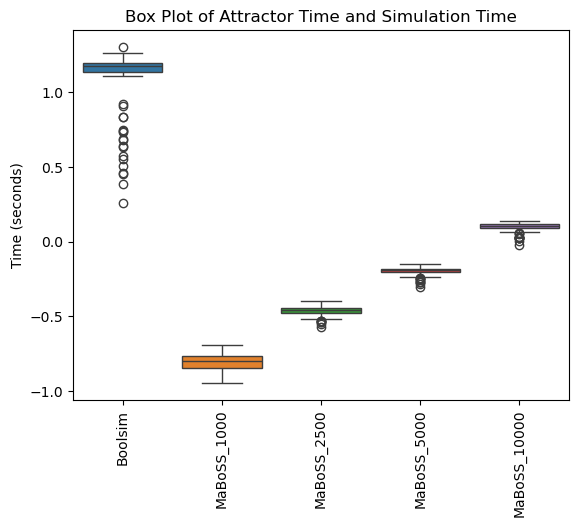

In [ ]:
import seaborn as sns

import matplotlib.pyplot as plt
overall_time = pd.DataFrame([attractor_time_df,simulation_time_df_1,simulation_time_df_2,simulation_time_df_3,simulation_time_df_4], 
                            index = ['Boolsim','MaBoSS_1000',
                                     'MaBoSS_2500','MaBoSS_5000','MaBoSS_10000']).T
overall_time.to_csv('comparing_SimulationTime_Invasion.csv')

# Create a box plot
sns.boxplot(data=np.log10(overall_time))
plt.title("Box Plot of Attractor Time and Simulation Time")
plt.ylabel("Time (log10 seconds))")
plt.xticks(rotation= 90)
plt.show()